In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [8]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data['time'] = pd.to_datetime(data['time'])

In [9]:
# Tree-based processed splits (unscaled, interpretable — used for task 15, 16, 17)
X_train = pd.read_csv("../../../data/processed/exp_1/X_train_tree.csv")
X_test  = pd.read_csv("../../../data/processed/exp_1/X_test_tree.csv")
y_train = pd.read_csv("../../../data/processed/exp_1/y_train.csv").squeeze("columns")
y_test  = pd.read_csv("../../../data/processed/exp_1/y_test.csv").squeeze("columns")

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}  |  column: '{y_train.name}'")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (14025, 51)
X_test shape  : (3506, 51)
y_train shape : (14025,)  |  column: 'target'
y_test shape  : (3506,)


### 27. Lag Feature Distribution Analysis

In [10]:
# The processed tree splits already contain pre-engineered lag features
# pm2_5_lag_1 through pm2_5_lag_12 (lags for all pollutants + met vars also present)
pm25_lag_cols = [c for c in X_train.columns if c.startswith('pm2_5_lag')]
print(f"PM2.5 lag features found in X_train_tree: {pm25_lag_cols}")

lag_df = X_train[['pm2_5'] + pm25_lag_cols].copy()
print(f"\nDescriptive stats for PM2.5 lag features:")
lag_df.describe().T[['mean','std','min','50%','max']]

PM2.5 lag features found in X_train_tree: ['pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_4', 'pm2_5_lag_5', 'pm2_5_lag_6', 'pm2_5_lag_7', 'pm2_5_lag_8', 'pm2_5_lag_9', 'pm2_5_lag_10', 'pm2_5_lag_11', 'pm2_5_lag_12']

Descriptive stats for PM2.5 lag features:


,mean,std,min,50%,max
pm2_5,28.921070,15.201627,0.6,26.3,124.8
pm2_5_lag_1,28.924848,15.205201,0.6,26.3,124.8
pm2_5_lag_2,28.928777,15.208772,0.6,26.3,124.8
pm2_5_lag_3,28.932970,15.212402,0.6,26.3,124.8
pm2_5_lag_4,28.938524,15.219928,0.6,26.3,124.8
pm2_5_lag_5,28.944050,15.226029,0.6,26.3,124.8
pm2_5_lag_6,28.949176,15.230609,0.6,26.3,124.8
pm2_5_lag_7,28.953947,15.234680,0.6,26.3,124.8
pm2_5_lag_8,28.958831,15.238685,0.6,26.3,124.8
pm2_5_lag_9,28.963922,15.243208,0.6,26.3,124.8


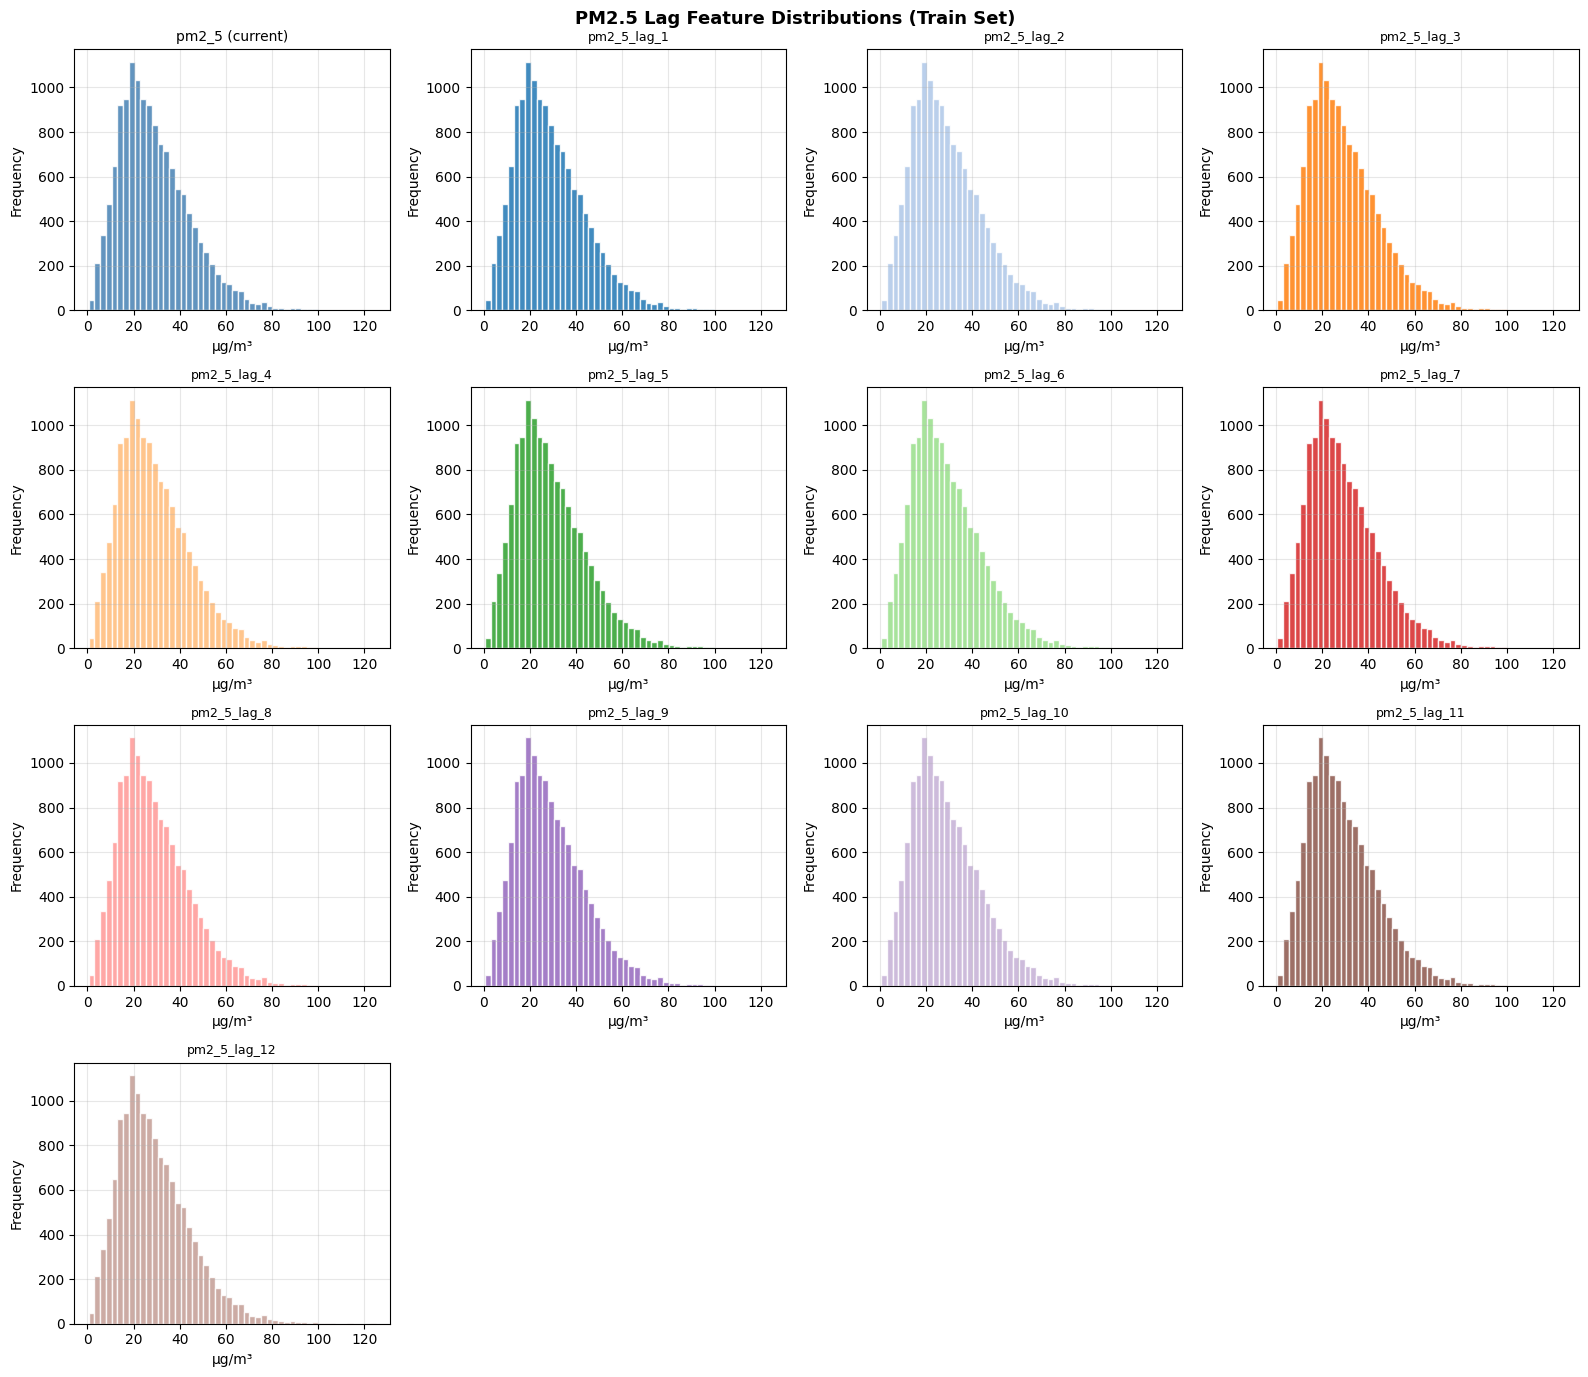

In [11]:
# Histograms: original pm2_5 + each lag feature
n_lags = len(pm25_lag_cols)
n_cols = 4
n_rows = int(np.ceil((n_lags + 1) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

axes[0].hist(lag_df['pm2_5'], bins=50, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('pm2_5 (current)', fontsize=10)
axes[0].set_xlabel('µg/m³')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

colors = plt.cm.tab20.colors
for i, col in enumerate(pm25_lag_cols):
    ax = axes[i + 1]
    ax.hist(lag_df[col].dropna(), bins=50, color=colors[i % 20], alpha=0.85, edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('µg/m³')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(n_lags + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('PM2.5 Lag Feature Distributions (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

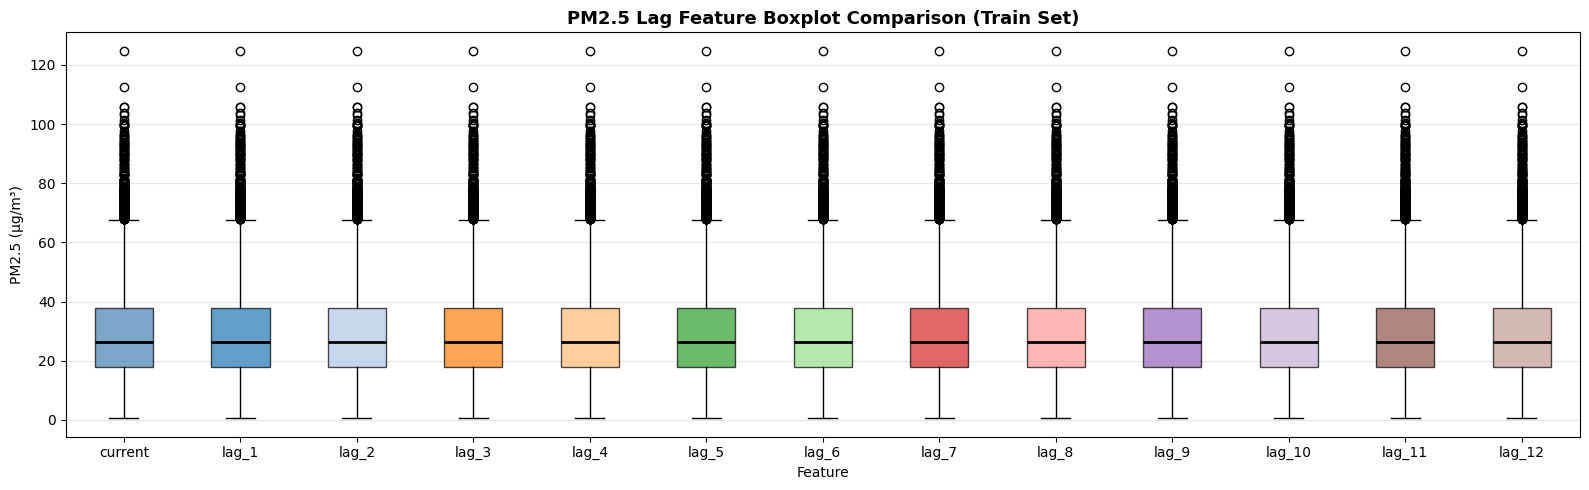

In [12]:
# Boxplot comparison of pm2_5 and all lag features
plot_cols = ['pm2_5'] + pm25_lag_cols
plot_data = [lag_df[c].dropna().values for c in plot_cols]
labels    = ['current'] + [c.replace('pm2_5_lag_', 'lag_') for c in pm25_lag_cols]

fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(plot_data, labels=labels, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

box_colors = ['steelblue'] + list(plt.cm.tab20.colors[:len(pm25_lag_cols)])
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('PM2.5 Lag Feature Boxplot Comparison (Train Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Pearson correlation of lag features with pm2_5 (train set):
   lag      r  p_value
 lag_1 0.9638      0.0
 lag_2 0.9085      0.0
 lag_3 0.8514      0.0
 lag_4 0.7967      0.0
 lag_5 0.7474      0.0
 lag_6 0.7050      0.0
 lag_7 0.6709      0.0
 lag_8 0.6453      0.0
 lag_9 0.6268      0.0
lag_10 0.6148      0.0
lag_11 0.6048      0.0
lag_12 0.5963      0.0


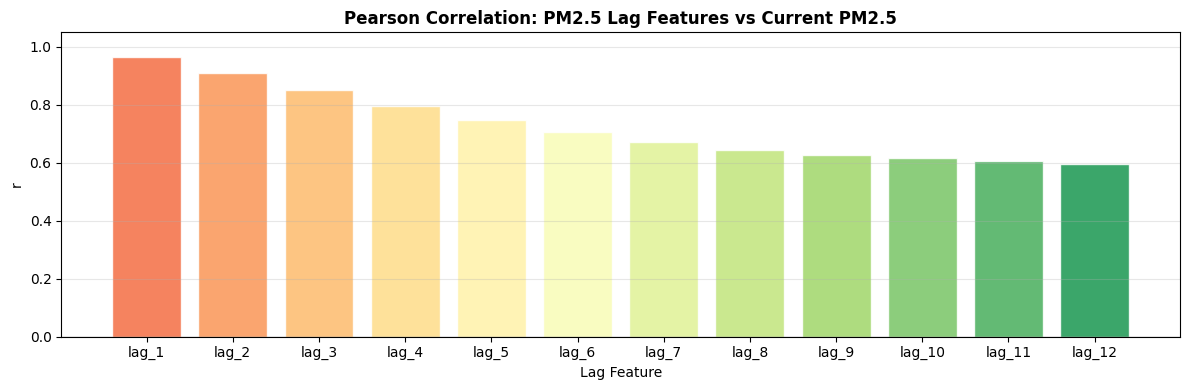

In [13]:
# Pearson correlation of each lag feature with the training target
corr_rows = []
for col in pm25_lag_cols:
    valid = lag_df[['pm2_5', col]].dropna()
    r, p  = stats.pearsonr(valid['pm2_5'], valid[col])
    corr_rows.append({'lag': col.replace('pm2_5_lag_', 'lag_'), 'r': round(r, 4), 'p_value': round(p, 6)})

corr_df = pd.DataFrame(corr_rows)
print("Pearson correlation of lag features with pm2_5 (train set):")
print(corr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(corr_df)))
ax.bar(corr_df['lag'], corr_df['r'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation: PM2.5 Lag Features vs Current PM2.5', fontsize=12, fontweight='bold')
ax.set_xlabel('Lag Feature')
ax.set_ylabel('r')
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Also check other pollutant lag groups (pm10, co, no2, so2, ozone)
other_lag_groups = {
    'pm10'           : [c for c in X_train.columns if c.startswith('pm10_lag')],
    'carbon_monoxide': [c for c in X_train.columns if c.startswith('carbon_monoxide_lag')],
    'nitrogen_dioxide': [c for c in X_train.columns if c.startswith('nitrogen_dioxide_lag')],
    'sulphur_dioxide': [c for c in X_train.columns if c.startswith('sulphur_dioxide_lag')],
    'ozone'          : [c for c in X_train.columns if c.startswith('ozone_lag')],
}

print("Lag features available per pollutant:")
for pollutant, cols in other_lag_groups.items():
    print(f"  {pollutant:20s}: {cols}")

Lag features available per pollutant:
  pm10                : ['pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3']
  carbon_monoxide     : ['carbon_monoxide_lag_1', 'carbon_monoxide_lag_2', 'carbon_monoxide_lag_3']
  nitrogen_dioxide    : ['nitrogen_dioxide_lag_1', 'nitrogen_dioxide_lag_2', 'nitrogen_dioxide_lag_3']
  sulphur_dioxide     : ['sulphur_dioxide_lag_1', 'sulphur_dioxide_lag_2', 'sulphur_dioxide_lag_3']
  ozone               : ['ozone_lag_1', 'ozone_lag_2', 'ozone_lag_3']


### 28. Train-Test Distribution Comparison

In [15]:
# Basic statistics of target (PM2.5) in train vs test
# y_train and y_test are raw PM2.5 targets (µg/m³), column name = 'target'
print("=== PM2.5 Target: Train vs Test Summary ===")
summary = pd.DataFrame({
    f'Train (n={len(y_train)})': y_train.describe(),
    f'Test  (n={len(y_test)})' : y_test.describe()
})
print(summary.to_string())

=== PM2.5 Target: Train vs Test Summary ===
       Train (n=14025)  Test  (n=3506)
count     14025.000000     3506.000000
mean         28.917305       37.480918
std          15.198189       29.903478
min           0.600000        0.400000
25%          17.800000       16.400000
50%          26.300000       24.700000
75%          37.700000       51.900000
max         124.800000      164.400000


In [16]:
# Kolmogorov-Smirnov Test
ks_stat, ks_pval = stats.ks_2samp(y_train.values, y_test.values)
print("=== Kolmogorov-Smirnov Test: y_train vs y_test ===")
print(f"KS Statistic : {ks_stat:.4f}")
print(f"P-value      : {ks_pval:.6f}")
if ks_pval < 0.05:
    print("Result       : Distributions are SIGNIFICANTLY DIFFERENT (p < 0.05) — distribution drift present")
else:
    print("Result       : No significant distribution drift detected (p >= 0.05)")

=== Kolmogorov-Smirnov Test: y_train vs y_test ===
KS Statistic : 0.1750
P-value      : 0.000000
Result       : Distributions are SIGNIFICANTLY DIFFERENT (p < 0.05) — distribution drift present


In [17]:
# Population Stability Index (PSI)
def compute_psi(expected, actual, buckets=10):
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    bins = np.linspace(min_val, max_val, buckets + 1)
    exp_counts, _ = np.histogram(expected, bins=bins)
    act_counts, _ = np.histogram(actual,   bins=bins)
    exp_pct = np.where(exp_counts == 0, 1e-4, exp_counts / len(expected))
    act_pct = np.where(act_counts == 0, 1e-4, act_counts / len(actual))
    psi_val = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi_val, bins, exp_pct, act_pct

psi_val, bins, exp_pct, act_pct = compute_psi(y_train.values, y_test.values)
print(f"PSI (Population Stability Index): {psi_val:.4f}")
if psi_val < 0.1:
    print("Interpretation: No significant shift (PSI < 0.1)")
elif psi_val < 0.2:
    print("Interpretation: Moderate shift — monitor carefully (0.1 <= PSI < 0.2)")
else:
    print("Interpretation: Significant shift — investigate further (PSI >= 0.2)")

PSI (Population Stability Index): 0.5416
Interpretation: Significant shift — investigate further (PSI >= 0.2)


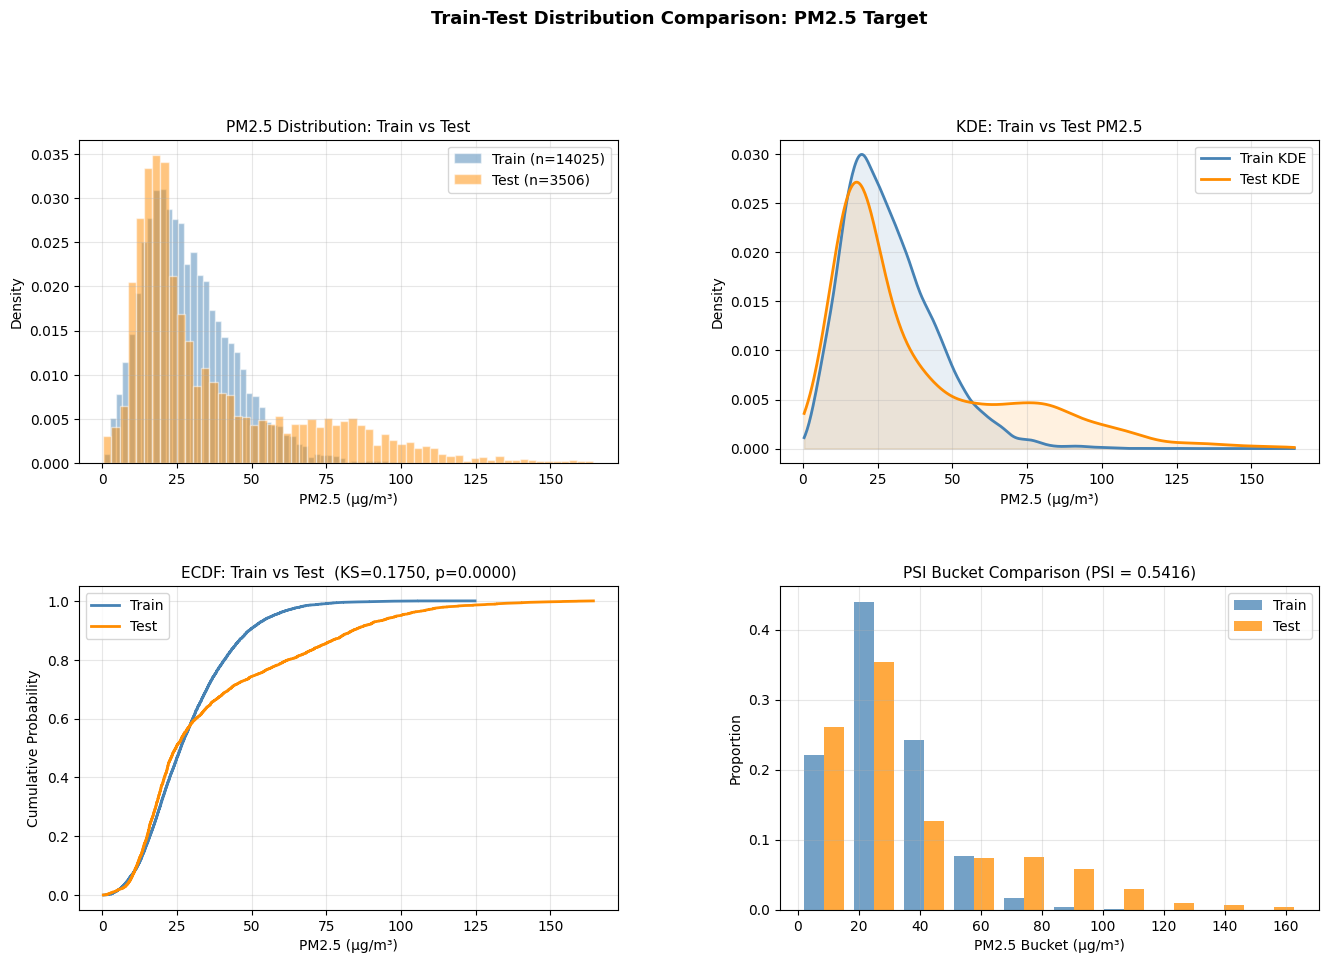

In [18]:
# Visual comparison: histogram overlay, KDE, ECDF, PSI bucket chart
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# Histogram overlay
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(y_train, bins=60, alpha=0.5, color='steelblue',  label=f'Train (n={len(y_train)})', density=True, edgecolor='white')
ax1.hist(y_test,  bins=60, alpha=0.5, color='darkorange', label=f'Test (n={len(y_test)})',   density=True, edgecolor='white')
ax1.set_title('PM2.5 Distribution: Train vs Test', fontsize=11)
ax1.set_xlabel('PM2.5 (µg/m³)')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# KDE overlay
ax2 = fig.add_subplot(gs[0, 1])
x_range = np.linspace(min(y_train.min(), y_test.min()),
                      max(y_train.max(), y_test.max()), 500)
ax2.plot(x_range, stats.gaussian_kde(y_train)(x_range), color='steelblue',   linewidth=2, label='Train KDE')
ax2.plot(x_range, stats.gaussian_kde(y_test)(x_range),  color='darkorange',  linewidth=2, label='Test KDE')
ax2.fill_between(x_range, stats.gaussian_kde(y_train)(x_range), alpha=0.12, color='steelblue')
ax2.fill_between(x_range, stats.gaussian_kde(y_test)(x_range),  alpha=0.12, color='darkorange')
ax2.set_title('KDE: Train vs Test PM2.5', fontsize=11)
ax2.set_xlabel('PM2.5 (µg/m³)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ECDF
ax3 = fig.add_subplot(gs[1, 0])
for arr, label, color in [(np.sort(y_train.values), 'Train', 'steelblue'),
                           (np.sort(y_test.values),  'Test',  'darkorange')]:
    ecdf = np.arange(1, len(arr) + 1) / len(arr)
    ax3.plot(arr, ecdf, label=label, color=color, linewidth=2)
ax3.set_title(f'ECDF: Train vs Test  (KS={ks_stat:.4f}, p={ks_pval:.4f})', fontsize=11)
ax3.set_xlabel('PM2.5 (µg/m³)')
ax3.set_ylabel('Cumulative Probability')
ax3.legend()
ax3.grid(True, alpha=0.3)

# PSI bucket comparison
ax4 = fig.add_subplot(gs[1, 1])
bw = (bins[1] - bins[0]) * 0.4
bin_centers = 0.5 * (bins[:-1] + bins[1:])
ax4.bar(bin_centers - bw/2, exp_pct, width=bw, alpha=0.75, color='steelblue',  label='Train', align='center')
ax4.bar(bin_centers + bw/2, act_pct, width=bw, alpha=0.75, color='darkorange', label='Test',  align='center')
ax4.set_title(f'PSI Bucket Comparison (PSI = {psi_val:.4f})', fontsize=11)
ax4.set_xlabel('PM2.5 Bucket (µg/m³)')
ax4.set_ylabel('Proportion')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Train-Test Distribution Comparison: PM2.5 Target', fontsize=13, fontweight='bold', y=1.01)
plt.show()

In [19]:
# Feature-level KS test across X_train_tree columns
common_cols = [c for c in X_train.columns if c in X_test.columns]
ks_results = []
for col in common_cols:
    stat, pval = stats.ks_2samp(X_train[col].dropna(), X_test[col].dropna())
    ks_results.append({
        'feature' : col,
        'ks_stat' : round(stat, 4),
        'p_value' : round(pval, 6),
        'drift'   : 'YES' if pval < 0.05 else 'NO'
    })

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)
drift_count = (ks_df['drift'] == 'YES').sum()
print(f"KS Test Results — features with drift: {drift_count}/{len(ks_df)}")
print()
print(ks_df.to_string(index=False))

KS Test Results — features with drift: 47/51

                   feature  ks_stat  p_value drift
                 month_sin   0.6203 0.000000   YES
                 month_cos   0.3172 0.000000   YES
          surface_pressure   0.2021 0.000000   YES
    surface_pressure_lag_1   0.2018 0.000000   YES
           sulphur_dioxide   0.1873 0.000000   YES
     sulphur_dioxide_lag_1   0.1869 0.000000   YES
     sulphur_dioxide_lag_2   0.1866 0.000000   YES
     sulphur_dioxide_lag_3   0.1862 0.000000   YES
                     pm2_5   0.1746 0.000000   YES
               pm2_5_lag_1   0.1743 0.000000   YES
               pm2_5_lag_2   0.1739 0.000000   YES
               pm2_5_lag_3   0.1736 0.000000   YES
               pm2_5_lag_4   0.1732 0.000000   YES
               pm2_5_lag_5   0.1731 0.000000   YES
               pm2_5_lag_6   0.1731 0.000000   YES
               pm2_5_lag_7   0.1730 0.000000   YES
               pm2_5_lag_8   0.1729 0.000000   YES
               pm2_5_lag_9   0.1729 

### 29. Baseline Forecast Analysis (Naïve Persistence Model)

In [20]:
# Reconstruct ordered PM2.5 series from the raw data for baseline evaluation
full_series = data.set_index('time')['pm2_5'].sort_index()

# The processed split is 80/20 (14025 train, 3506 test)
split_idx   = 14025
test_series = full_series.iloc[split_idx:]
naive_pred  = full_series.shift(1).iloc[split_idx:]  # t-1 as prediction

valid = naive_pred.notna()
y_true_base = test_series[valid].values
y_pred_base = naive_pred[valid].values

def eval_metrics(y_true, y_pred, label):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2   = 1 - ss_res / ss_tot
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-6, y_true))) * 100
    return {'Model': label, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
            'R2': round(r2, 4), 'MAPE_%': round(mape, 4)}

m1 = eval_metrics(y_true_base, y_pred_base, 'Naive Persistence (t-1)')
print("=== Naive Persistence Baseline ===")
for k, v in m1.items(): print(f"  {k:35s}: {v}")

=== Naive Persistence Baseline ===
  Model                              : Naive Persistence (t-1)
  MAE                                : 3.8702
  RMSE                               : 7.8888
  R2                                 : 0.9304
  MAPE_%                             : 11.4928


In [21]:
# Lag-24 persistence (same hour yesterday) and 24h rolling mean baseline
naive_24  = full_series.shift(24).iloc[split_idx:]
valid_24  = naive_24.notna()
m2 = eval_metrics(test_series[valid_24].values, naive_24[valid_24].values,
                  'Naive Persistence (t-24, daily)')

roll_pred = full_series.rolling(window=24, min_periods=1).mean().shift(1).iloc[split_idx:]
valid_r   = roll_pred.notna()
m3 = eval_metrics(test_series[valid_r].values, roll_pred[valid_r].values,
                  'Rolling Mean Baseline (24h)')

metrics_df = pd.DataFrame([m1, m2, m3]).set_index('Model')
print("\n=== Baseline Model Comparison ===")
print(metrics_df.to_string())
print("\nNote: Compare these against your ML model metrics to confirm meaningful improvement.")
print("A strong ML model should beat Naive Persistence (t-1) on all metrics.")


=== Baseline Model Comparison ===
                                     MAE     RMSE      R2   MAPE_%
Model                                                             
Naive Persistence (t-1)           3.8702   7.8888  0.9304  11.4928
Naive Persistence (t-24, daily)   8.3103  12.4839  0.8256  29.1848
Rolling Mean Baseline (24h)      11.5050  17.5231  0.6563  38.2990

Note: Compare these against your ML model metrics to confirm meaningful improvement.
A strong ML model should beat Naive Persistence (t-1) on all metrics.


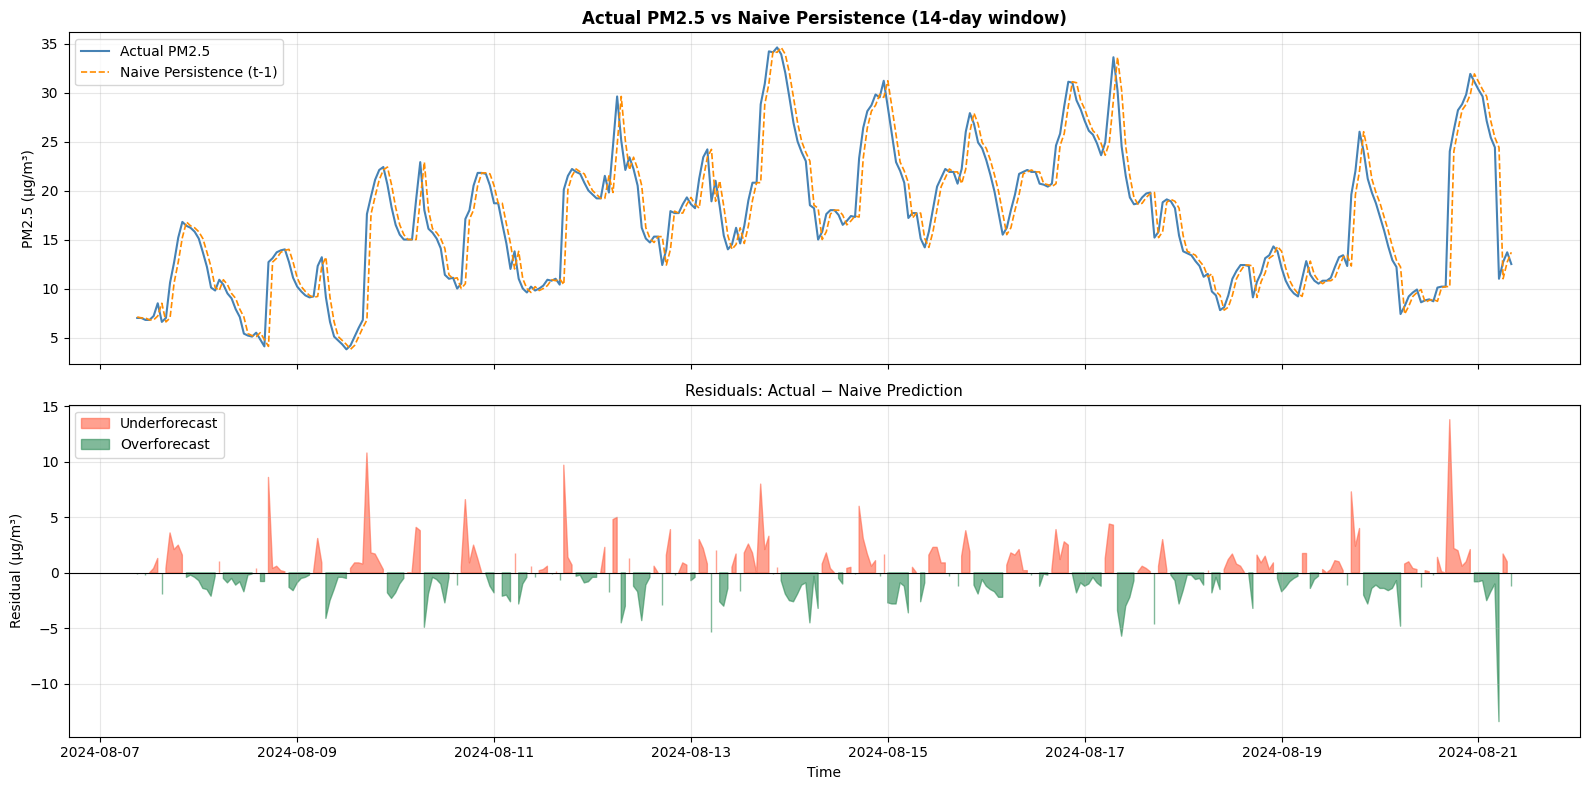

In [22]:
# Visual: actual vs naive persistence — 2-week window
plot_window = 336  # 14 days x 24h
plot_times  = test_series[valid].index[:plot_window]
y_true_plot = y_true_base[:plot_window]
y_pred_plot = y_pred_base[:plot_window]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(plot_times, y_true_plot, label='Actual PM2.5',           color='steelblue',  linewidth=1.5)
axes[0].plot(plot_times, y_pred_plot, label='Naive Persistence (t-1)', color='darkorange', linewidth=1.2, linestyle='--')
axes[0].set_title('Actual PM2.5 vs Naive Persistence (14-day window)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_true_plot - y_pred_plot
axes[1].fill_between(plot_times, residuals, 0, where=(residuals >= 0),
                     color='tomato',   alpha=0.6, label='Underforecast')
axes[1].fill_between(plot_times, residuals, 0, where=(residuals < 0),
                     color='seagreen', alpha=0.6, label='Overforecast')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals: Actual − Naive Prediction', fontsize=11)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Residual (µg/m³)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

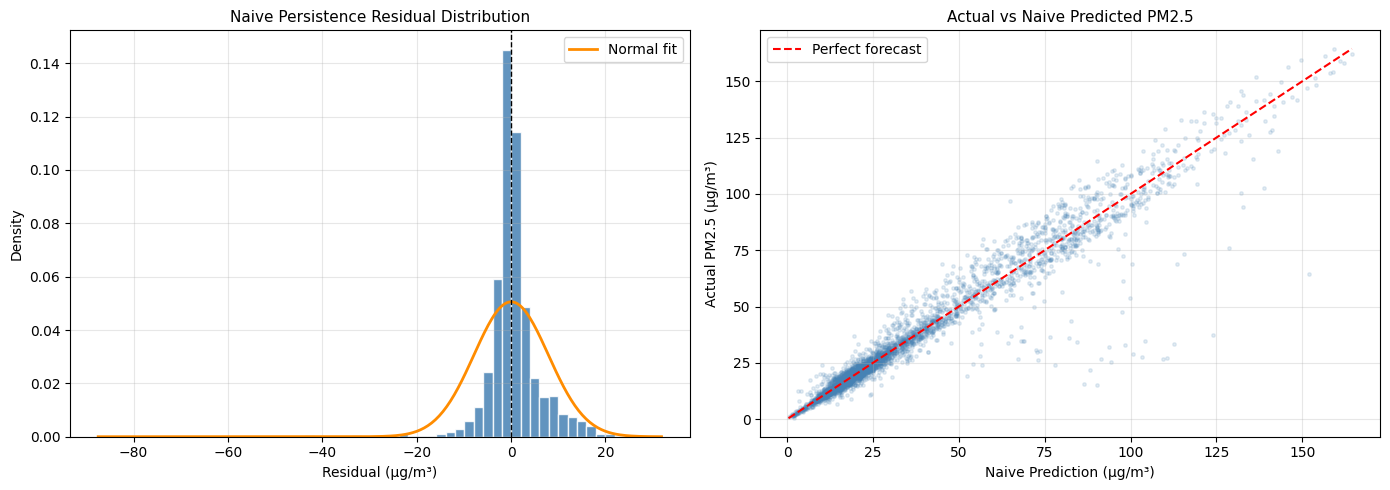

In [23]:
# Residual distribution + scatter plot
all_residuals = y_true_base - y_pred_base

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_residuals, bins=60, color='steelblue', alpha=0.85, edgecolor='white', density=True)
x_r = np.linspace(all_residuals.min(), all_residuals.max(), 300)
axes[0].plot(x_r, stats.norm.pdf(x_r, all_residuals.mean(), all_residuals.std()),
             color='darkorange', linewidth=2, label='Normal fit')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Naive Persistence Residual Distribution', fontsize=11)
axes[0].set_xlabel('Residual (µg/m³)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_base, y_true_base, alpha=0.15, s=6, color='steelblue')
lims = [min(y_true_base.min(), y_pred_base.min()), max(y_true_base.max(), y_pred_base.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect forecast')
axes[1].set_title('Actual vs Naive Predicted PM2.5', fontsize=11)
axes[1].set_xlabel('Naive Prediction (µg/m³)')
axes[1].set_ylabel('Actual PM2.5 (µg/m³)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()